## Python For Machine Learning Fall 2025
---
# Attention and Transformer

# 1. Overview

This notebook implements the step-by-step calculations described in Jay Alammar's **[The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/)**. This notebook consists of two parts:

- Manual Calculation (Numpy)
We use `numpy` to manually calculate the core mechanisms:
    1.  **Positional Encodings**
    2.  **Self-Attention** (Query, Key, Value)
    3.  **Multi-Head Attention**
    4.  **Residuals & Normalization**

- Part 2: Full Implementation (PyTorch)
    5.  **Toy Transformer Implementation**
    6.  **Training on a Real Dataset** (Translation)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

np.random.seed(73)

print("Packages loaded.")

Packages loaded.


# 1. Self-Attention

## 1.1 Inputs & Embeddings (Manual)

We start with input words (e.g., "Thinking", "Machines"). To make the calculation process easier to follow, we demonstrate this using a 4-dimensional toy embedding.

* **Input:** 2 words ("Thinking", "Machines")
* **d_model:** 4

In [ ]:
d_model = 4  # Embedding size

# Create Input Embeddings (X)
x1 = np.array([1, 0, 1, 0])  # "Thinking"
x2 = np.array([0, 2, 0, 2])  # "Machines"

X = np.array([x1, x2])

print("Input Matrix X (Shape: {}):".format(X.shape))
print(X)

Input Matrix X (Shape: (2, 4)):
[[1 0 1 0]
 [0 2 0 2]]


## 1.2 Positional Encoding

Since the Transformer processes all words simultaneously (non-recurrent), it needs a way to understand the order of words. We add a position-specific vector to each input embedding. The positional encoding is calculated as follows:

$$PE_{(pos, 2i)} = \sin(pos / 10000^{2i/d_{model}})$$
$$PE_{(pos, 2i+1)} = \cos(pos / 10000^{2i/d_{model}})$$

Following the equations, we can define the function to calculate the positional encoding.

In [ ]:
def get_positional_encoding(seq_len, d_model):
    pe = np.zeros((seq_len, d_model))
    position = np.arange(0, seq_len).reshape(-1, 1)

    # Calculating the division term: 10000^(2i/d_model)
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))

    # Apply Sine to even indices
    pe[:, 0::2] = np.sin(position * div_term)

    # Apply Cosine to odd indices
    pe[:, 1::2] = np.cos(position * div_term)

    return pe

Let's generate PEs for a longer sequence to visualize the pattern

In [ ]:
seq_len_demo = 20
d_model_demo = 64
pe = get_positional_encoding(seq_len_demo, d_model_demo)
print(pe.shape)

(20, 64)


Visualize the PEs.

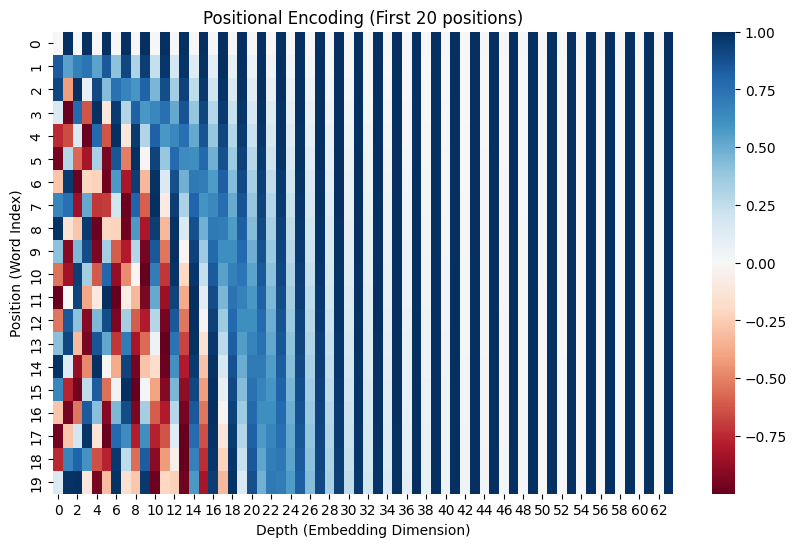

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(pe, cmap="RdBu", center=0)
plt.title(f"Positional Encoding (First {seq_len_demo} positions)")
plt.xlabel("Depth (Embedding Dimension)")
plt.ylabel("Position (Word Index)")
plt.show()

Now we can generate the PEs for our input and then add them to the word embeddings.

In [ ]:
pe_toy = get_positional_encoding(2, 4)
X_embedded = X + pe_toy

print("Input X + Positional Encoding:")
print(np.round(X_embedded, 2))

Input X + Positional Encoding:
[[1.   1.   1.   1.  ]
 [0.84 2.54 0.01 3.  ]]


## 1.3 Self-Attention

Self-Attention is the core of the transformer. We want to calculate how much "Thinking" should attend to "Machines" (and itself).


### 1.3.1 Create Q, K, V

We multiply input $X$ by three weight matrices: $W^Q$, $W^K$, $W^V$.
For this toy example, let's use a **Key/Query/Value dimension ($d_k$) of 3**. Please note that the dimension is usually bigger (paper uses 64).*italicized text*

Initialize Weight Matrices randomly.

In [ ]:
d_k = 3  # Dimension of Q, K, V ()

# Initialize Weight Matrices randomly
W_Q = np.random.randint(2, size=(d_model, d_k))
W_K = np.random.randint(2, size=(d_model, d_k))
W_V = np.random.randint(2, size=(d_model, d_k))

print("W_Q:"); print(W_Q)
print("\nW_K:"); print(W_K)
print("\nW_V:"); print(W_V)

W_Q:
[[0 0 0]
 [0 0 0]
 [1 1 0]
 [0 1 1]]

W_K:
[[0 1 0]
 [1 1 0]
 [1 1 1]
 [0 1 0]]

W_V:
[[0 0 0]
 [1 1 1]
 [1 1 1]
 [0 1 1]]


Calculate Q, K, V. The dimension will change 4 -> 3.

In [ ]:
Q = np.dot(X_embedded, W_Q)
K = np.dot(X_embedded, W_K)
V = np.dot(X_embedded, W_V)

print("\nQuery Matrix (Q):"); print(np.round(Q, 2))
print("Key Matrix (K):"); print(np.round(K, 2))
print("Value Matrix (V):"); print(np.round(V, 2))


Query Matrix (Q):
[[1.   2.   1.  ]
 [0.01 3.01 3.  ]]
Key Matrix (K):
[[2.   4.   1.  ]
 [2.55 6.39 0.01]]
Value Matrix (V):
[[2.   3.   3.  ]
 [2.55 5.55 5.55]]


### 1.3.2 Calculate Scores

The dot product is used in self-attention primarily because it is a computationally efficient proxy for semantic similarity. Geometrically, the dot product measures the alignment between two vectors; if a "Query" vector (what you are looking for) and a "Key" vector (what the token contains) point in a similar direction in the high-dimensional embedding space, their dot product yields a large positive scalar. This large scalar, after being passed through a Softmax function, becomes a high "attention weight," effectively telling the model to focus more on that specific token. While other metrics like cosine similarity or Euclidean distance could theoretically work, the dot product allows the entire attention mechanism to be calculated via highly optimized matrix multiplications $Q \times Q^K$, making it significantly faster and more parallelizable on modern hardware like GPUs.

In [ ]:
scores = np.dot(Q, K.T)

print("Raw Scores (Q dot K_transpose):")
print(np.round(scores, 2))

Raw Scores (Q dot K_transpose):
[[11.   15.34]
 [15.06 19.29]]


### 1.3.3 Scale and Softmax

In self-attention, the scale factor ($\frac{1}{\sqrt{d_k}}$) is strictly required to prevent the vanishing gradient problem during training. When you calculate the dot product between two vectors (Query q and Key k) of dimension $d_k$, you are summing up $d_k$ individual products. If q and k are initialized with a standard variance of 1, the variance of their dot product grows linearly with the dimension $d_k$.
- For a small dimension (e.g., $d_k=64$), the values are manageable.
- For a large dimension (e.g., $d_k=1024$), the result of the dot product can become extremely large (positive or negative).

The softmax function becomes saturated and mimics a discrete argmax, which outputs a one-hot vector. Since this results in a near-zero local gradient, we need to divide by $\sqrt{d_k}$ to scale the input before we apply the softmax. The calculation here then become:

$$Attention(Q, K, V) = \text{softmax}(\frac{QK^T}{\sqrt{d_k}})V$$

In [ ]:
# Scale
dk_root = math.sqrt(d_k)
scaled_scores = scores / dk_root

# Softmax Function
def softmax(x):
    e_x = np.exp(x - np.max(x, axis=1, keepdims=True)) # max subtraction for stability
    return e_x / e_x.sum(axis=1, keepdims=True)

attention_weights = softmax(scaled_scores)

print("Attention Weights (Softmax):")
print(np.round(attention_weights, 2))

Attention Weights (Softmax):
[[0.08 0.92]
 [0.08 0.92]]


### 1.3.4 Weighted Sum
The final step of self-attention is to multiply the attention weights by the Value vectors $V$.

In [ ]:
Z = np.dot(attention_weights, V)

print("Self-Attention Output (Z):")
print(np.round(Z, 2))
print(f"Shape: {Z.shape}")

Self-Attention Output (Z):
[[2.51 5.36 5.36]
 [2.51 5.35 5.35]]
Shape: (2, 3)


## 1.4 Multi-Head Attention

In reality, we run the process above multiple times (e.g., 8 heads) in parallel with different weight matrices.
Then we **concatenate** the results and multiply by an output matrix $W^O$.
For this example, we will simulate 2 heads.

We have calculated the output for one head and randomly generated the output for the second head to demonstrate the process. You can randomly initialize the Q, K, and V matrices yourself to obtain new results.

In [ ]:
Z1 = Z
Z2 = np.random.rand(2, 3) # Random output for head 2

Concatenate $Z_1$ and $Z_2$. The shape becomes $[2, 6]$ because $d_k$ was $3$ and we have $2$ heads

In [ ]:
Z_concat = np.concatenate((Z1, Z2), axis=1)

print("Concatenated Heads (Z1 + Z2):")
print(np.round(Z_concat, 2))

Concatenated Heads (Z1 + Z2):
[[2.51 5.36 5.36 0.61 0.08 0.27]
 [2.51 5.35 5.35 0.59 0.42 0.63]]


Projects back to original `d_model` size (4) by multiplying Output Matrix $W_O$
The shape of W_O: [d_k * num_heads, d_model] -> [6, 4]

In [ ]:
W_O = np.random.rand(6, 4)
Z_multi_head = np.dot(Z_concat, W_O)

print("\nFinal Multi-Head Output:")
print(np.round(Z_multi_head, 2))
print(f"Shape: {Z_multi_head.shape}")


Final Multi-Head Output:
[[8.95 7.63 8.44 6.83]
 [9.32 8.04 9.01 7.07]]
Shape: (2, 4)


## 1.5 Add & Norm (Residuals)

The Transformer adds the original input to the output of the attention block (Residual Connection) and then normalizes it.

**Structure:** `LayerNorm(x + Sublayer(x))`

In [ ]:
def layer_norm(x, eps=1e-6):
    mean = x.mean(axis=-1, keepdims=True)
    std = x.std(axis=-1, keepdims=True)
    return (x - mean) / (std + eps)

Residual Connection: Add original input (X) to the attention output.

In [ ]:
residual_connection = X_embedded + Z_multi_head
output_layer = layer_norm(residual_connection)

print("Final Layer Output (Add & Norm):")
print(np.round(output_layer, 2))

Final Layer Output (Add & Norm):
[[ 1.23 -0.41  0.59 -1.41]
 [ 0.35  1.09 -1.63  0.19]]


# 2. Implementing a Functional Toy Transformer (PyTorch)

Now that we understand the math, we will implement a working "Toy" Transformer using **PyTorch**. This allows us to handle backpropagation (training) which is too complex to do manually with Numpy.



## 2.1 The Toy Model Class
We will build a simple Encoder-style Transformer (like BERT) for classification.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class ToyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers, output_dim):
        super(ToyTransformer, self).__init__()
        # Embeddings
        self.embedding = nn.Embedding(vocab_size, d_model)

        # Positional Encoding (Simplified learnable parameter for this toy example)
        self.pos_encoder = nn.Parameter(torch.randn(1, 100, d_model))

        # Transformer Encoder Layers
        # This packs Self-Attention, Multi-Head, FeedForward, and Add&Norm into one clean layer
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Final Prediction Layer
        self.fc = nn.Linear(d_model, output_dim)

    def forward(self, x):
        # x shape: [batch_size, seq_len]

        # Embed + Add Position
        seq_len = x.size(1)
        x = self.embedding(x) + self.pos_encoder[:, :seq_len, :]

        # Run through Transformer
        output = self.transformer_encoder(x)

        # We take the mean of all words to classify the whole sentence
        output = output.mean(dim=1)

        # Final prediction
        return self.fc(output)

## 2.2 Test on a "Real" Dataset

We will create a small real-world dataset for **Sentiment Analysis** (Positive vs Negative). This demonstrates how the model learns to associate word patterns with outcomes.

In [ ]:
# 1 = Positive, 0 = Negative
raw_data = [
    ("I love this movie", 1),
    ("This was the best day", 1),
    ("I like transformers", 1),
    ("I hate this movie", 0),
    ("This was the worst day", 0),
    ("I dislike machines", 0)
]

We will tokenize the dataset and convert it to tensor.

In [ ]:
# Map words to unique IDs
word_to_id = {"<PAD>": 0}
for sentence, _ in raw_data:
    for word in sentence.lower().split():
        if word not in word_to_id:
            word_to_id[word] = len(word_to_id)

print(f"Vocabulary Size: {len(word_to_id)}")

def encode_sentence(sent):
    return [word_to_id[w] for w in sent.lower().split()]

# Prepare Tensors
inputs = [torch.tensor(encode_sentence(s)) for s, _ in raw_data]
targets = torch.tensor([label for _, label in raw_data])


Vocabulary Size: 15


As Transformer only accept fixed length input. We will pad sentences to same length.

In [ ]:
padded_inputs = torch.nn.utils.rnn.pad_sequence(inputs, batch_first=True, padding_value=0)

print("\nProcessed Batch:")
print(padded_inputs)
print("Targets:", targets)


Processed Batch:
tensor([[ 1,  2,  3,  4,  0],
        [ 3,  5,  6,  7,  8],
        [ 1,  9, 10,  0,  0],
        [ 1, 11,  3,  4,  0],
        [ 3,  5,  6, 12,  8],
        [ 1, 13, 14,  0,  0]])
Targets: tensor([1, 1, 1, 0, 0, 0])


Traning in Pytorch is starightforward.

In [ ]:
# Hyperparameters
vocab_size = len(word_to_id)
d_model = 8       # Embedding size
nhead = 2         # Number of heads
num_layers = 1    # Number of transformer blocks
output_dim = 2    # 2 classes (Pos/Neg)

model = ToyTransformer(vocab_size, d_model, nhead, num_layers, output_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

print("Starting Training...")
for epoch in range(50):
    optimizer.zero_grad()

    # Forward pass
    outputs = model(padded_inputs)

    # Loss
    loss = criterion(outputs, targets)

    # Backward pass
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

print("Training Complete.")

Starting Training...
Epoch 10, Loss: 0.6325
Epoch 20, Loss: 0.3639
Epoch 30, Loss: 0.0965
Epoch 40, Loss: 0.0264
Epoch 50, Loss: 0.0068
Training Complete.


In [ ]:
test_sentence = "I love this machines"
test_tensor = torch.tensor(encode_sentence(test_sentence)).unsqueeze(0) # Add batch dim

with torch.no_grad():
    prediction = model(test_tensor)
    predicted_class = torch.argmax(prediction).item()

label_map = {1: "Positive", 0: "Negative"}
print(f"\nTest Sentence: '{test_sentence}'")
print(f"Model Prediction: {label_map[predicted_class]}")


Test Sentence: 'I love this machines'
Model Prediction: Positive
